So the previous notebook I was working on "advancementsims.ipynb" kinda crashed out, so we're starting fresh

In this notebook, I'll be making all the necessary plots for Chapter 1.1 
we want to answer the question: "How does the inclusion of topography in horizontal convection experiments affect the mangitude and spatial distribution of turbulent dissipation?

1.1 : Are the theoretical constraints on volume averaged mechanical energy dissipation and volume averaged buoyancy dissipation valid for topographically constrained horizontal convection?

End goal is to have a scatter plot with volume averaged dissipation parameter vs Ra with the theoretical constraint curves. 

We also want to plot the streamfunction of the experiments to see the circulation pattern and how it changes with topography. 

We also want to plot heatmaps of chi and epsilon at equilibrium to see the how they vary locally rather than averaged over volume. 

In [1]:
using TopographicHorizontalConvection:dissipation_analysis
using TopographicHorizontalConvection:plot_normalized
using TopographicHorizontalConvection:plot_avg
using TopographicHorizontalConvection:diss_norm_eq_subplots
using TopographicHorizontalConvection:get_ψ
using TopographicHorizontalConvection:streamfunction_subplots

In [2]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics
using Makie.Colors

In [3]:
#oceanostics data

ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/oceanostics.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/oceanostics.nc"));

list_of_datasets = [ds0_o, ds1_o, ds2_o, ds3_o]


#hills

ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

list_hill_datasets = [ds_h0_o, ds_h1_o, ds_h2_o, ds_h3_o];

In [4]:
#buoyancy data

ds0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/buoyancy.nc"));
ds1 = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds2 = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/buoyancy.nc"));

list_ds_buoy = [ds0, ds1, ds2, ds3];


ds_h0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h1 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h2 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));

list_hill_ds_buoy = [ds_h0, ds_h1, ds_h2, ds_h3];

In [5]:
#import velocity data 

ds0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/velocities.nc"));
ds1_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_velocities.nc"));
ds2_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/velocities.nc"));

list_ds_vel = [ds0_v, ds1_v, ds2_v, ds3_v];


ds_h0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_velocities.nc"));
ds_h1_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_velocities.nc"));
ds_h2_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds_h3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_velocities.nc"));

list_hill_ds_vel = [ds_h0_v, ds_h1_v, ds_h2_v, ds_h3_v];

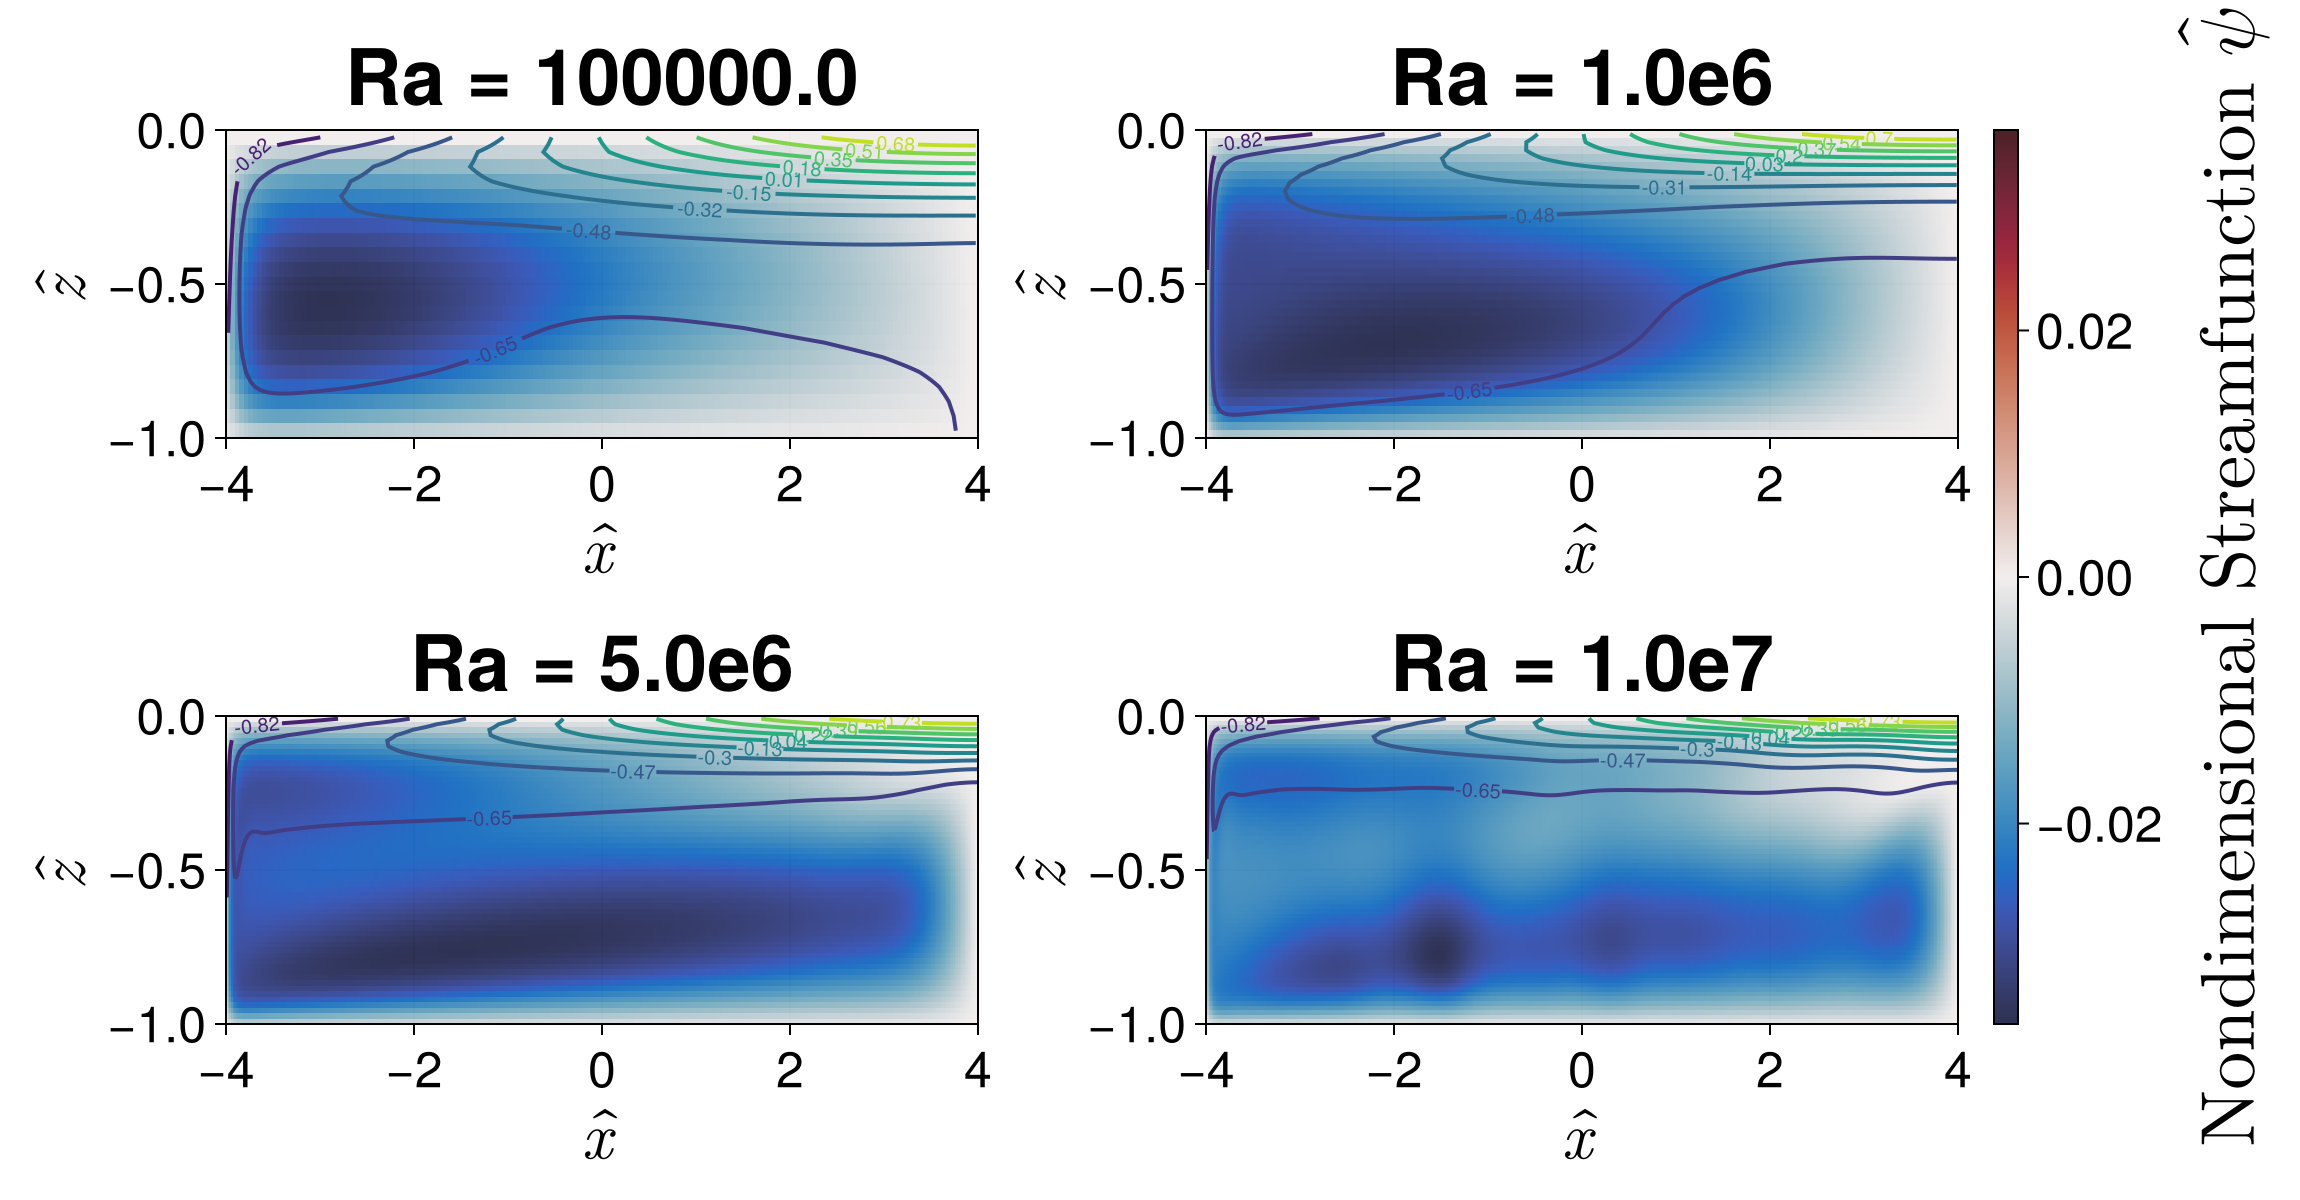

In [6]:
# Create streamfunction subplots for no-hill datasets
fig_no_hills = streamfunction_subplots(list_ds_buoy, list_ds_vel, cols=2)
fig_no_hills

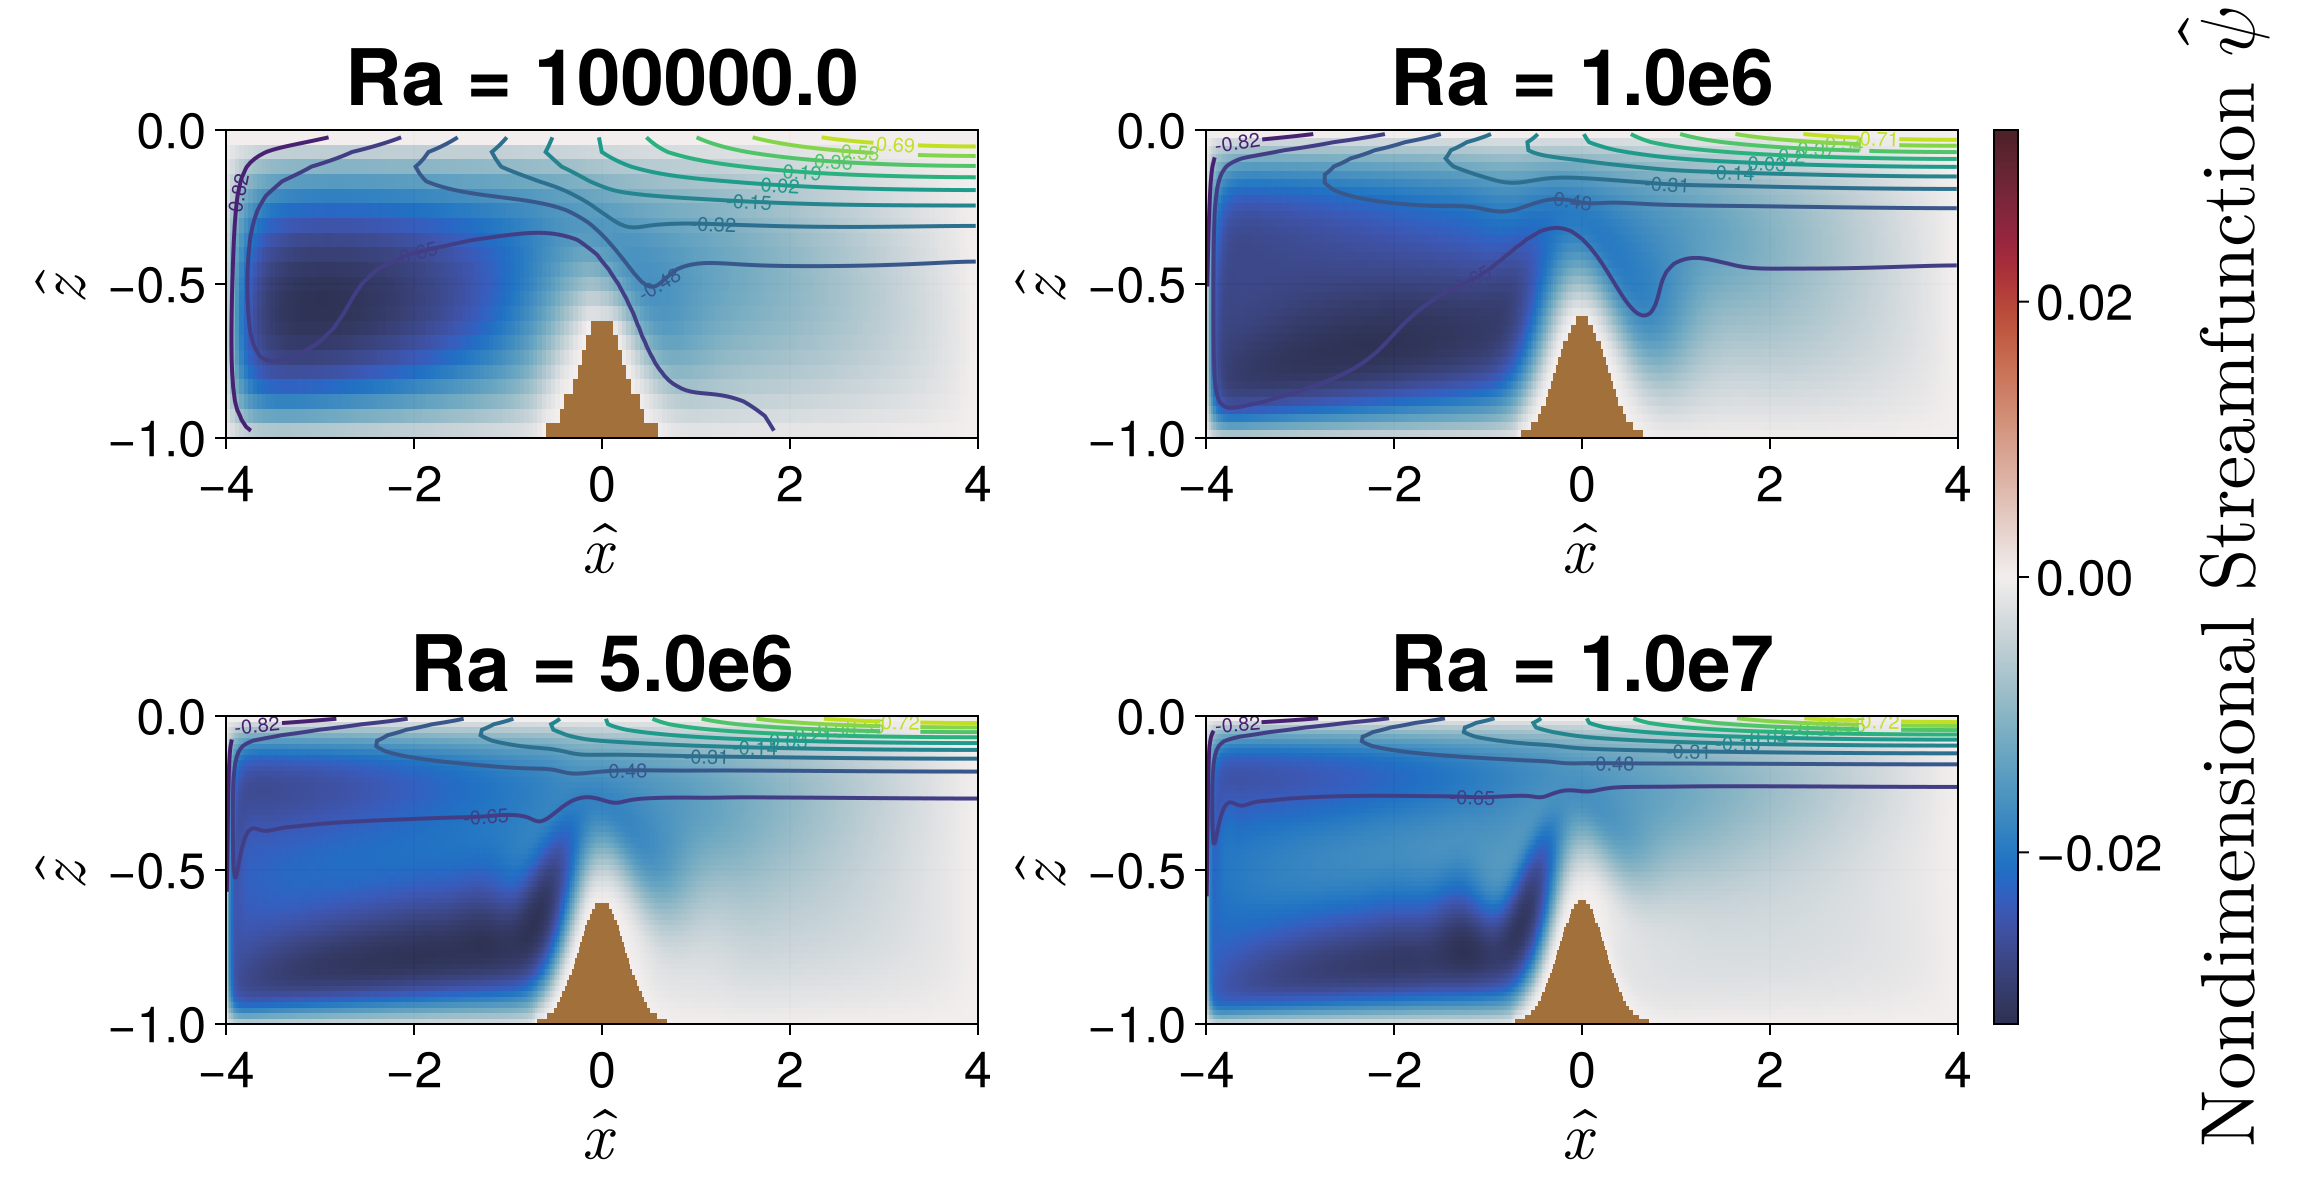

In [7]:
# Create streamfunction subplots for hill datasets
fig_hills = streamfunction_subplots(list_hill_ds_buoy, list_hill_ds_vel, cols=2)
fig_hills

Replot the epsilon and chi heatmaps at equilibrium

1.1165379723056392-4.5729301196518281.551297152421942-4.9253431299230851.6714516771819392-3.97632972606663951.617282092562957-2.740456085968314

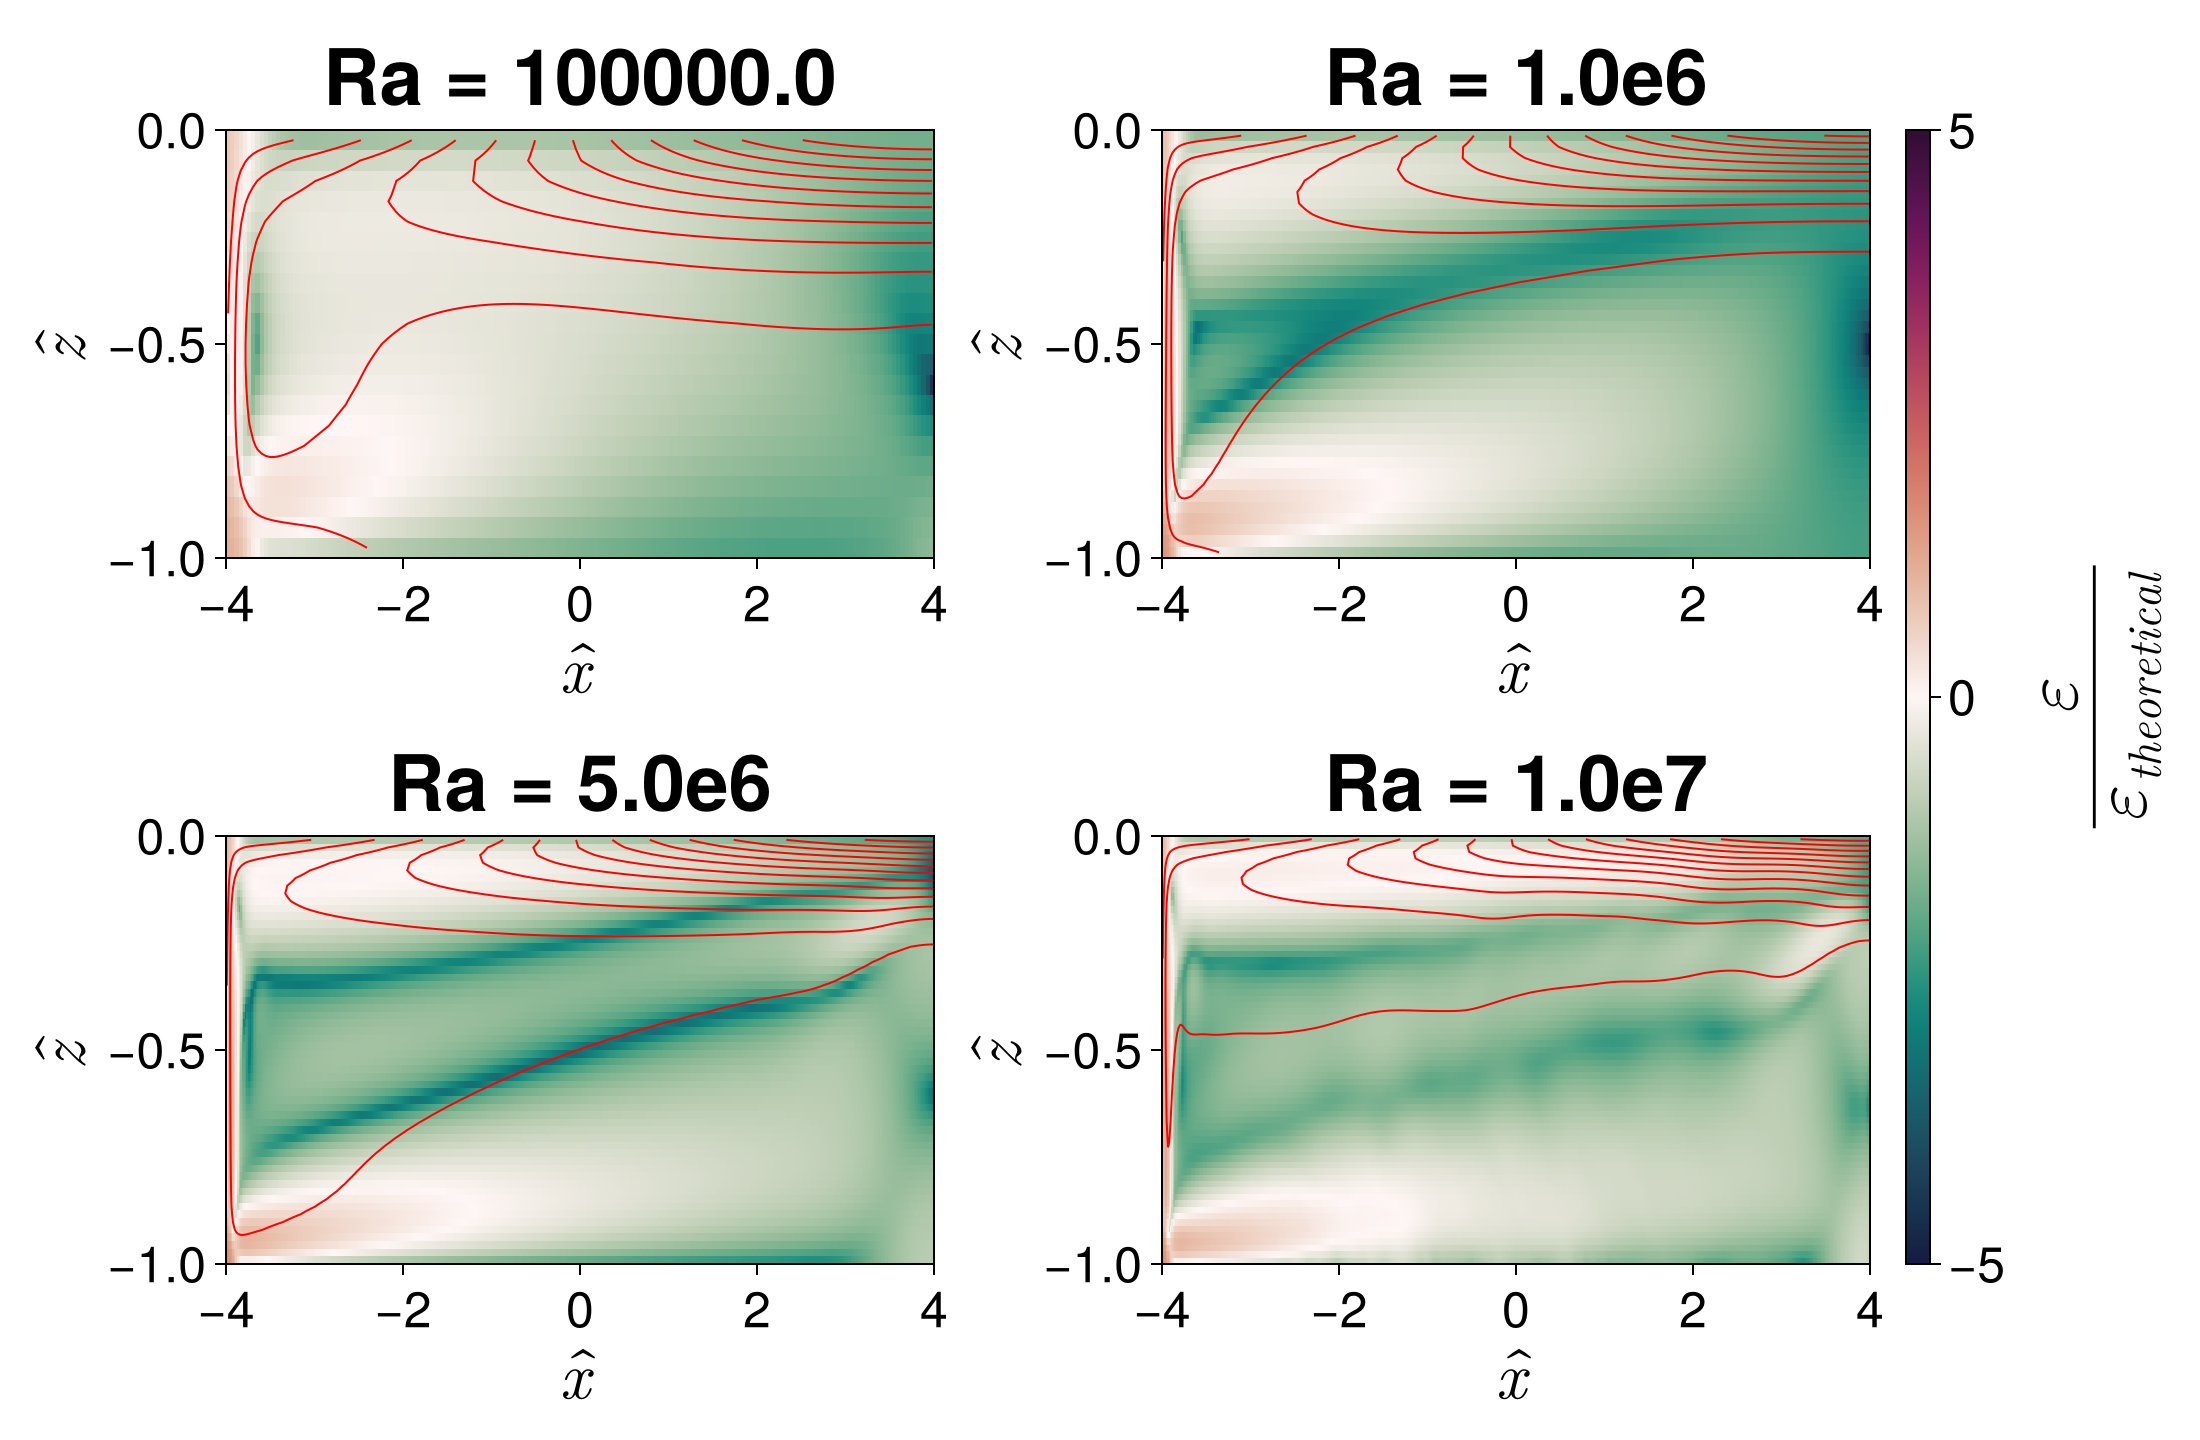

In [8]:
ep_hm_flat = diss_norm_eq_subplots(list_of_datasets, list_ds_buoy, "ε", (-5,5), cols=2)
ep_hm_flat

1.112336523974345-Inf1.5649845955476205-Inf1.9730407869024675-Inf2.1107484641555776-Inf

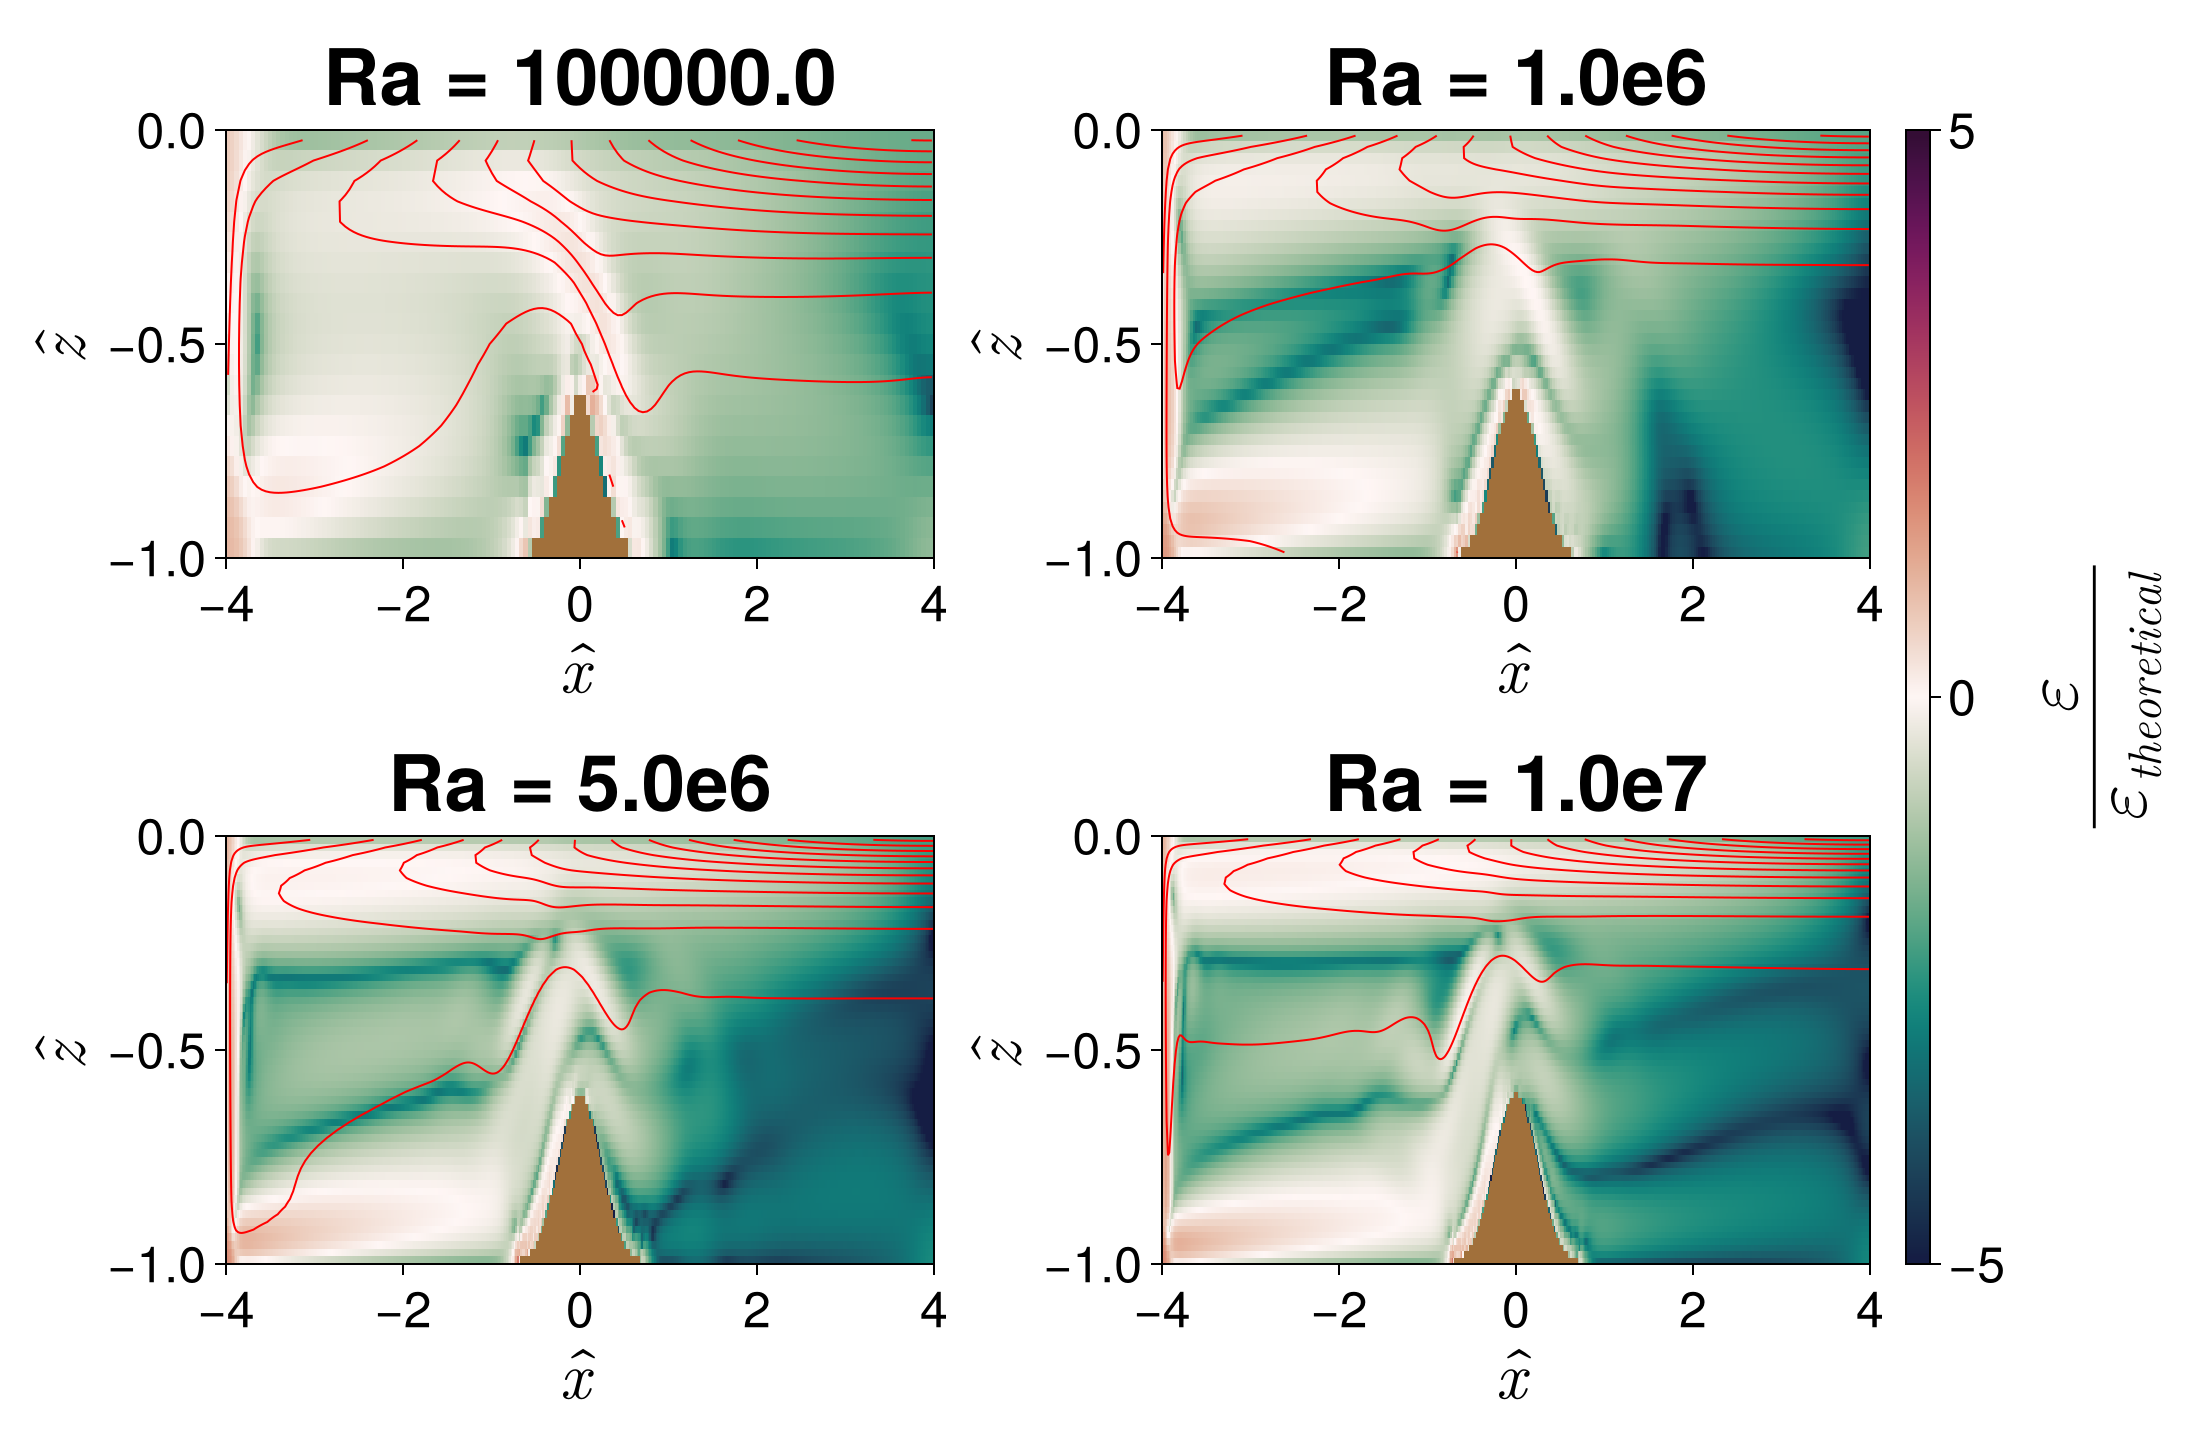

In [9]:
ep_hm_hill = diss_norm_eq_subplots(list_hill_datasets, list_hill_ds_buoy, "ε", (-5, 5), cols=2)
ep_hm_hill

-1.1294085043299575-7.2307280361453845-1.1072589630731615-11.84498661365274-1.2255086383737808-9.230247051709295-1.1748396356812882-8.50407105336638

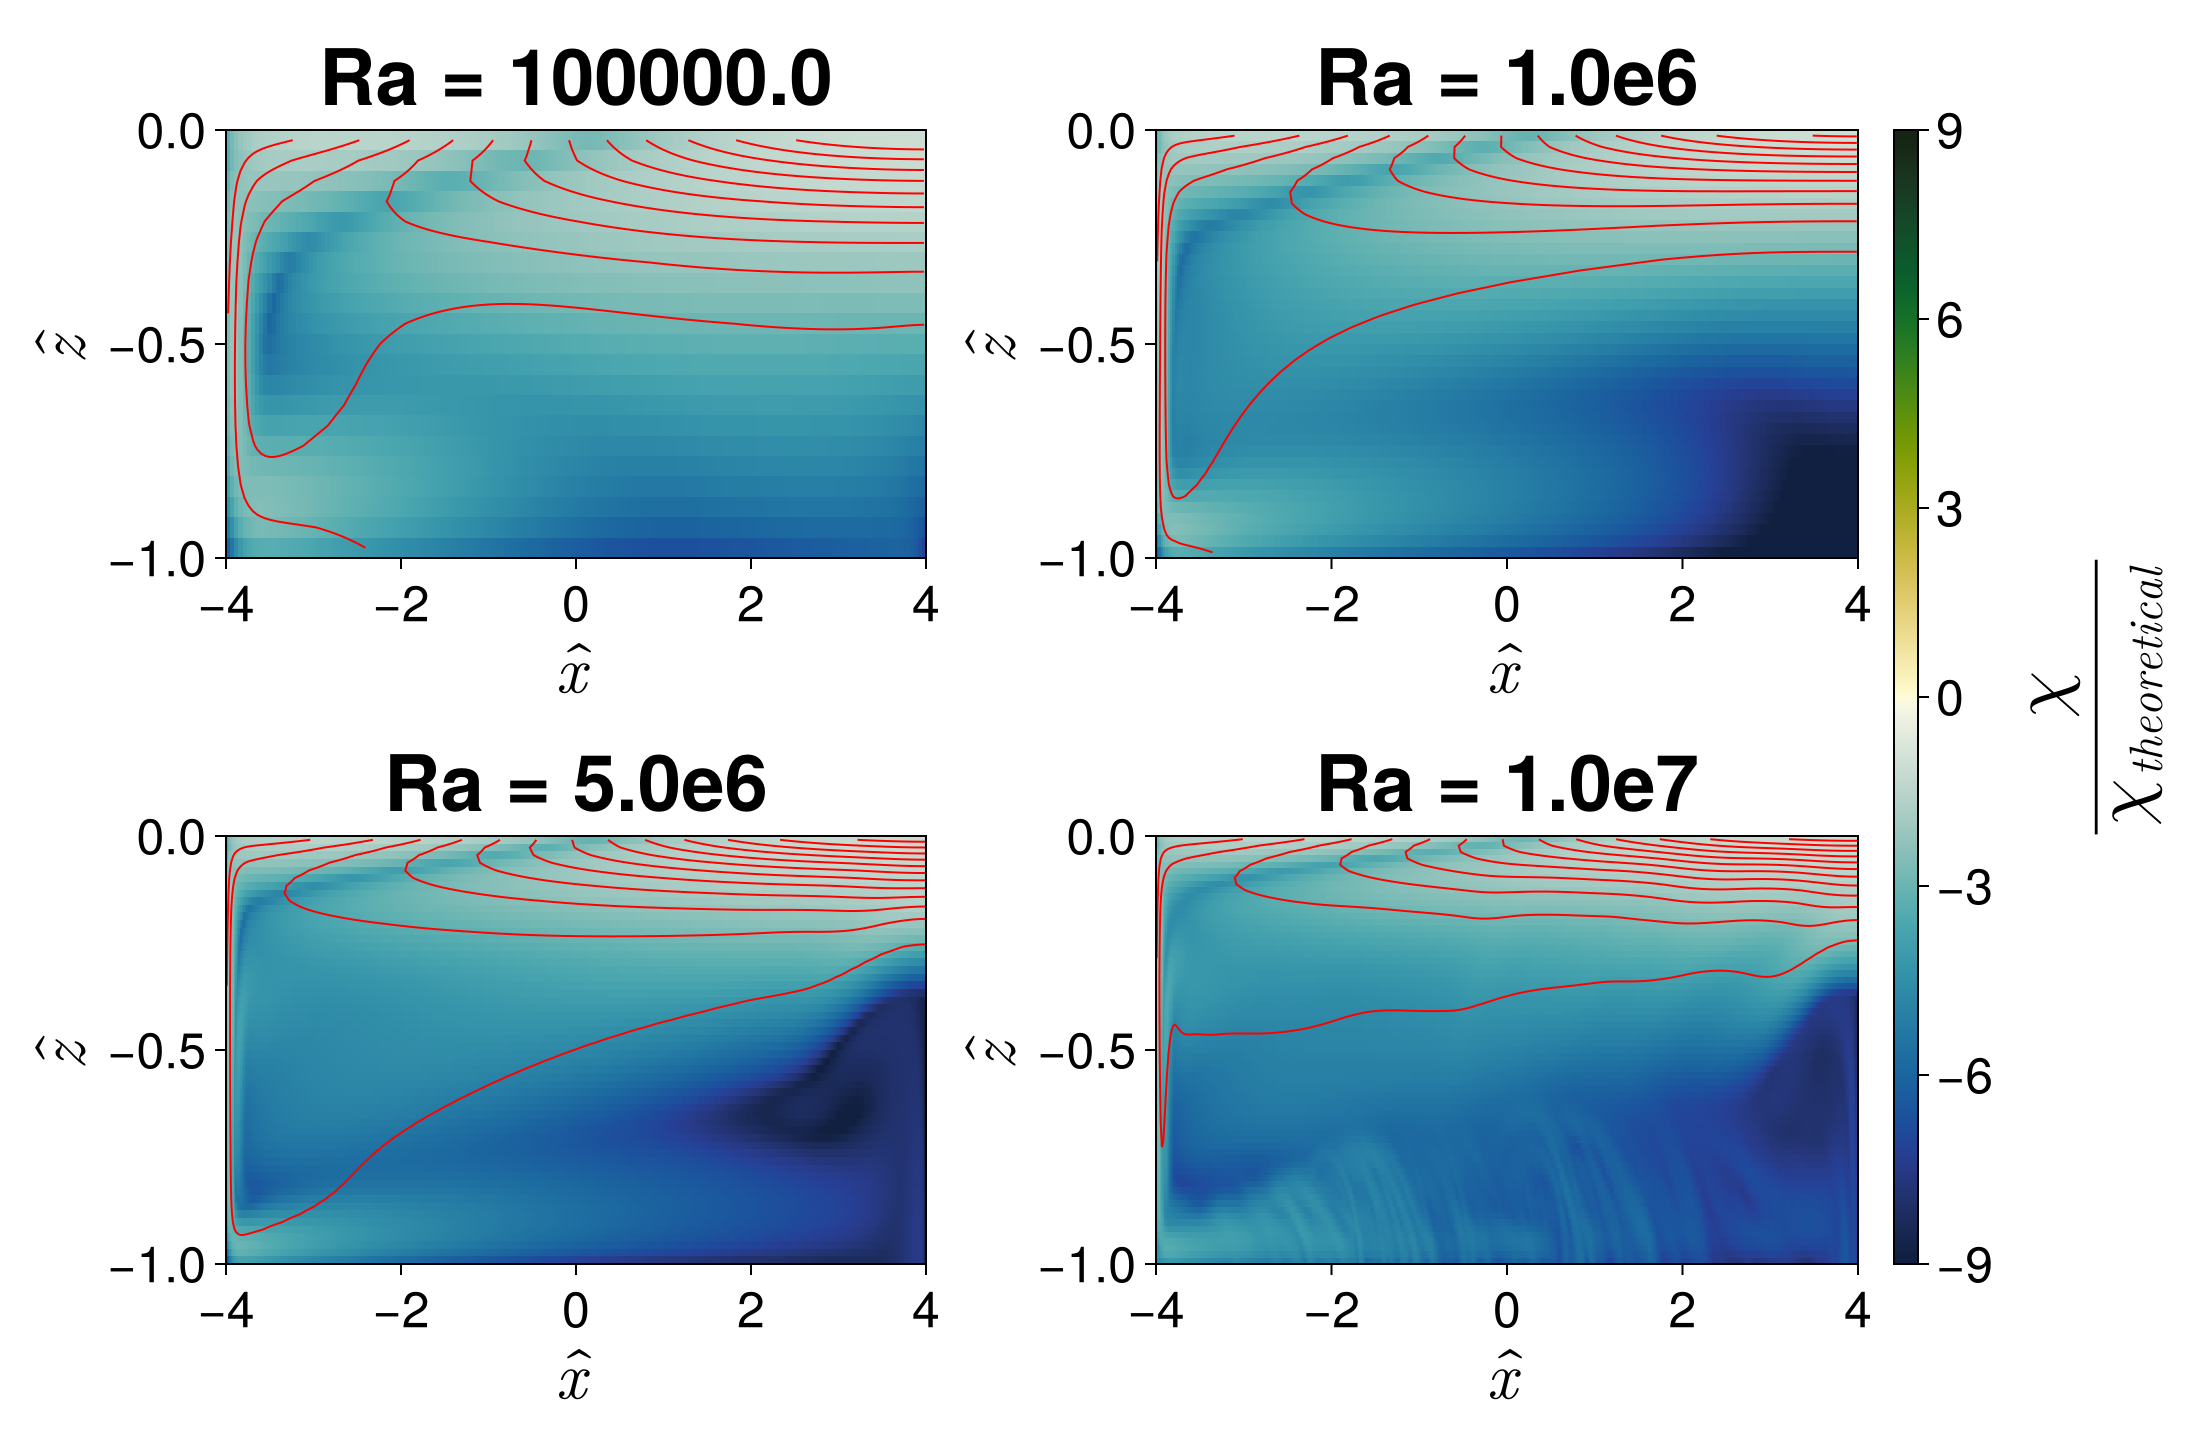

In [10]:
chi_hm_flat = diss_norm_eq_subplots(list_of_datasets, list_ds_buoy, "χ", (-9, 9), cols=2)
chi_hm_flat

-1.210499688235989-Inf-1.1329989399257896-Inf-1.1038520147176958-Inf-1.0893255032419924-Inf

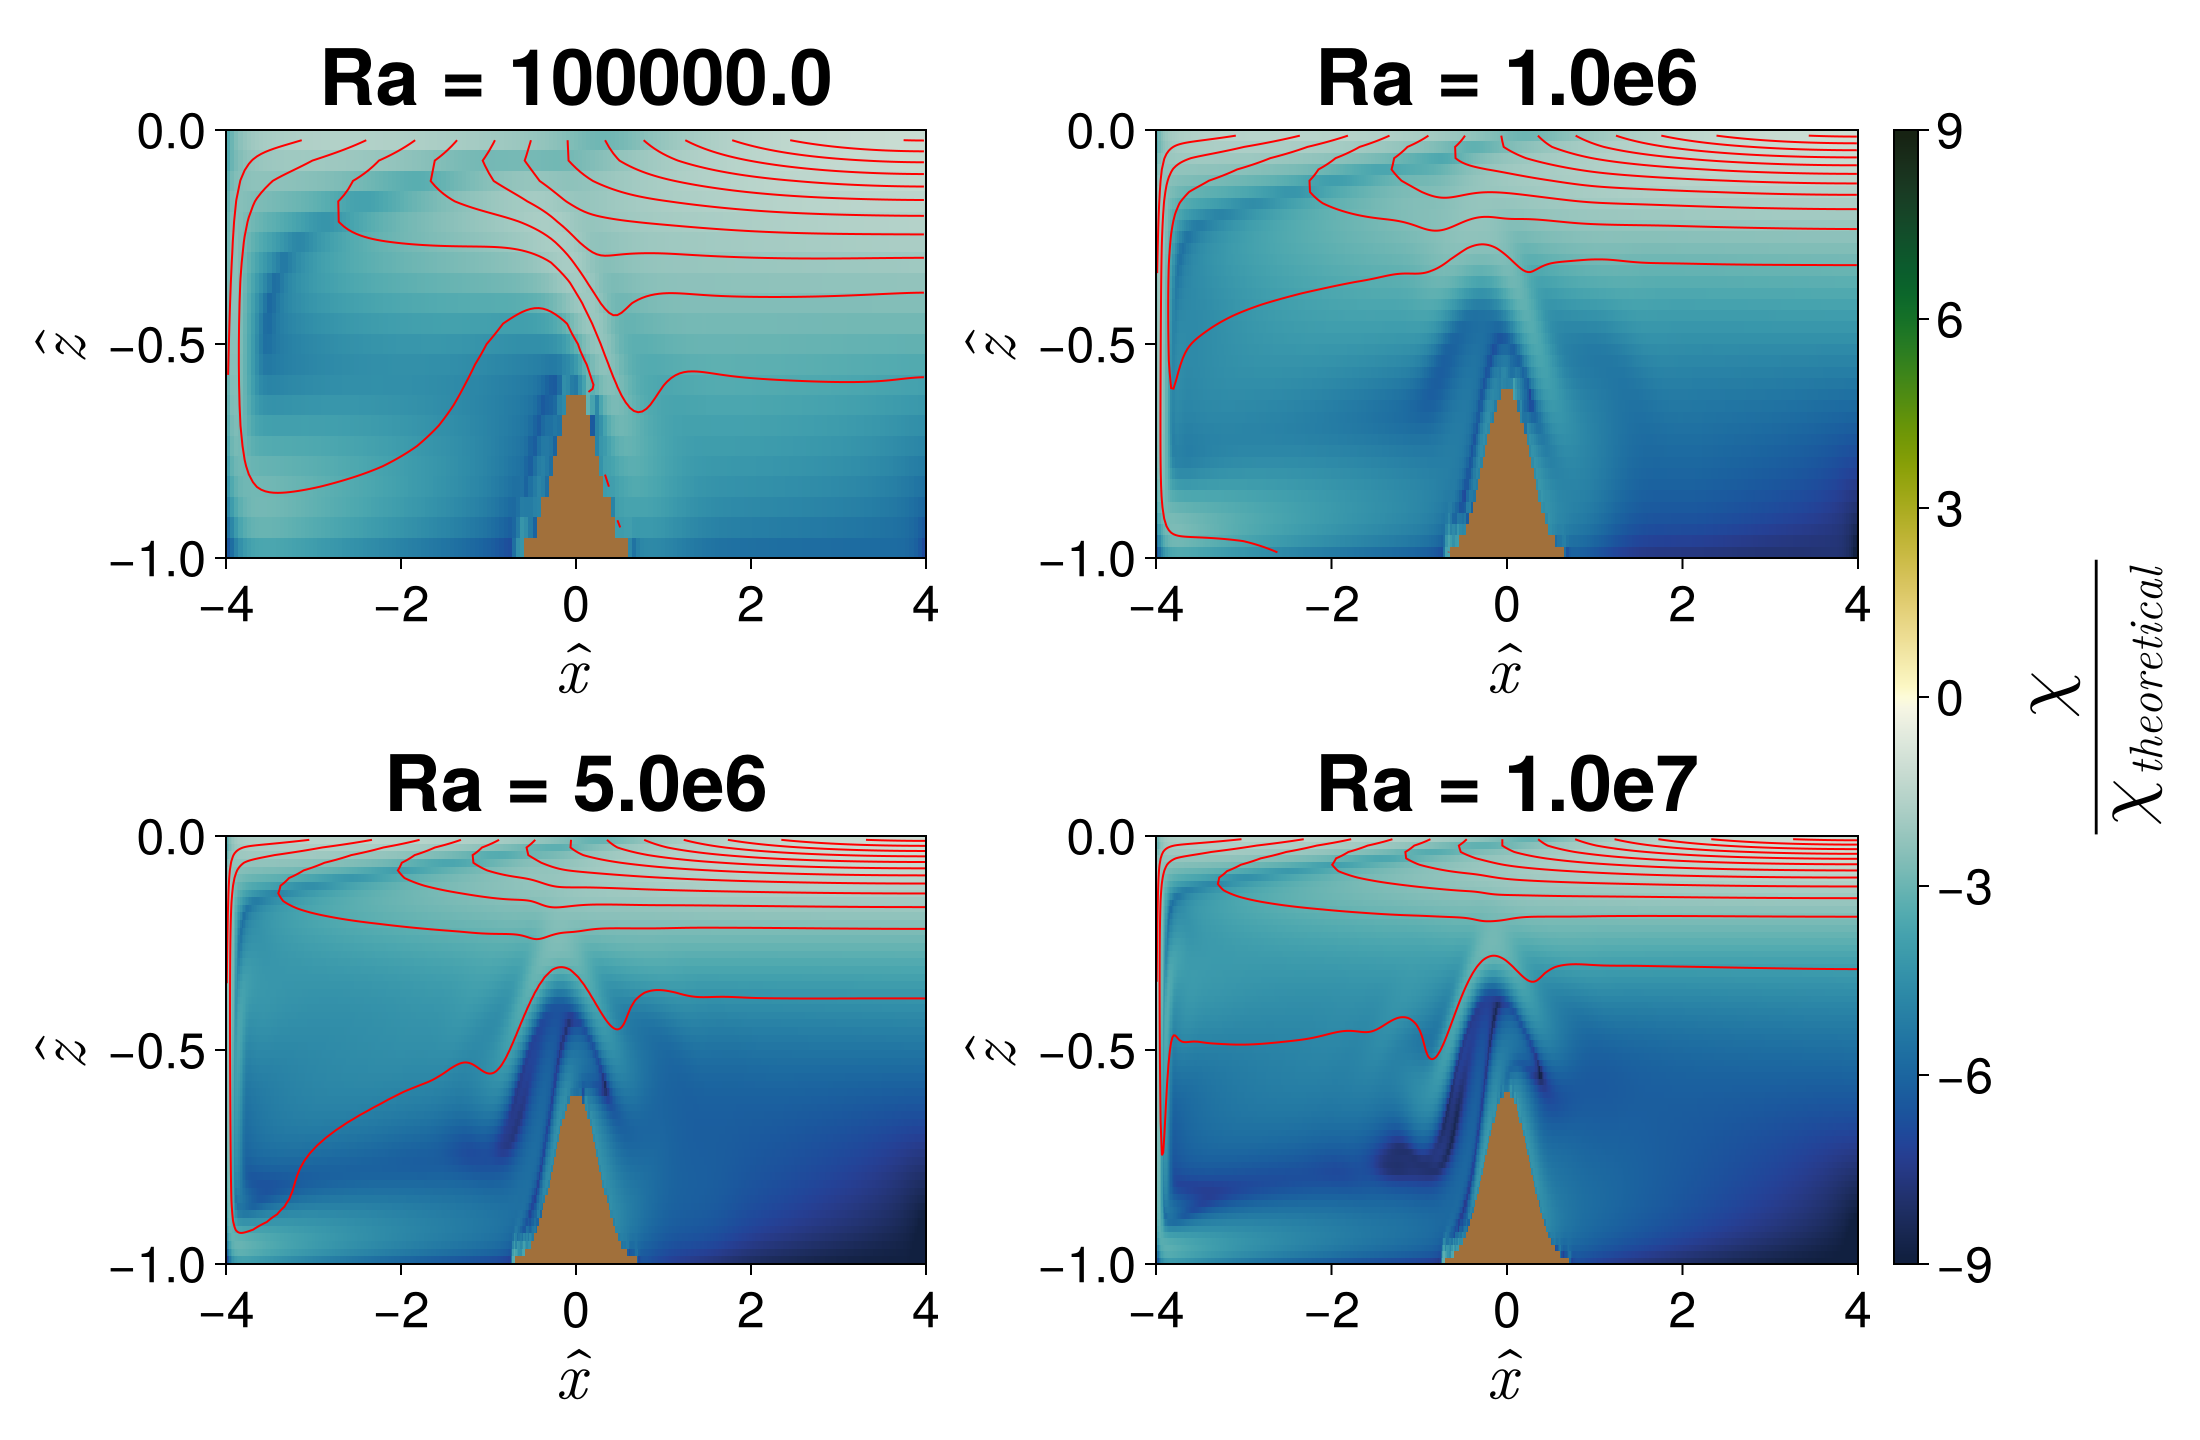

In [11]:
chi_hm_hill = diss_norm_eq_subplots(list_hill_datasets, list_hill_ds_buoy, "χ", (-9, 9), cols=2)
chi_hm_hill

Scatter plots!!!!!

first up is epsilon no hills

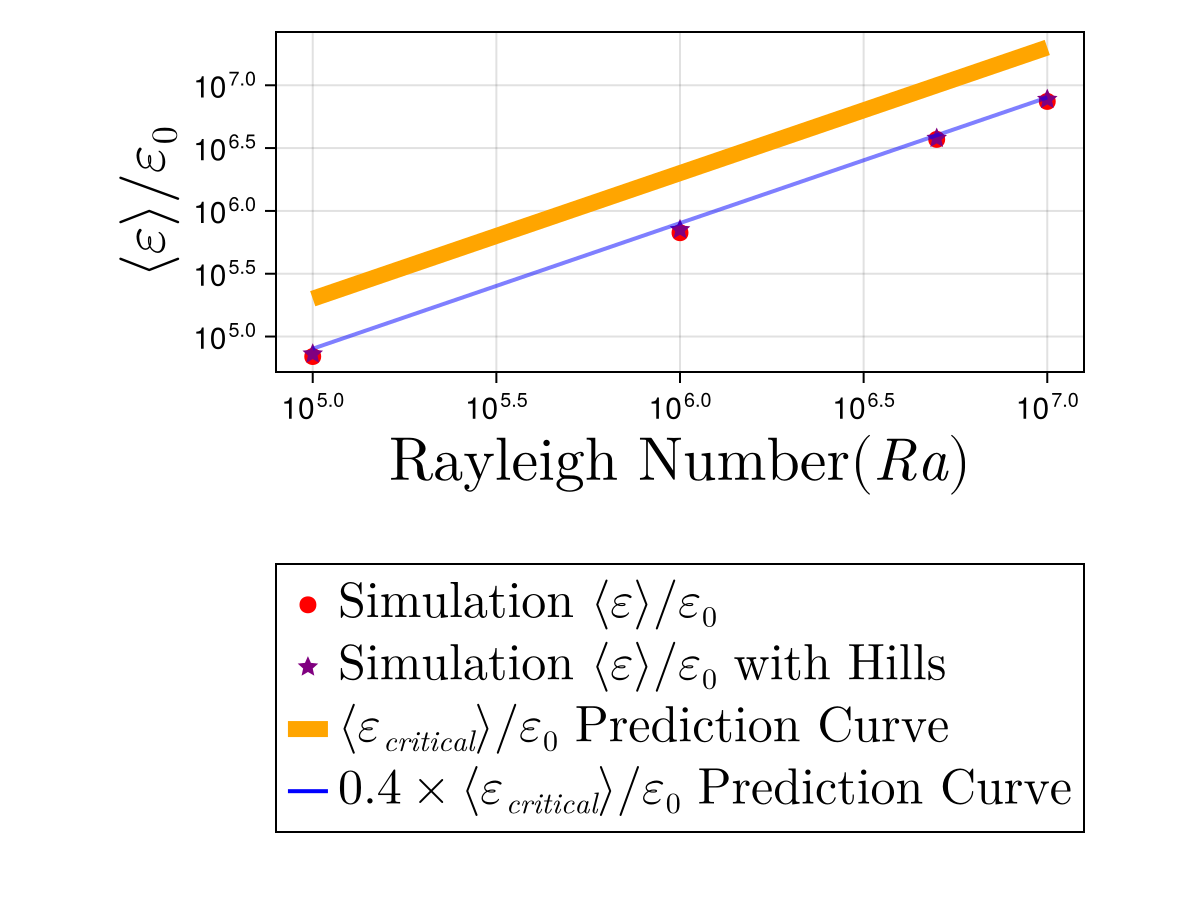

In [12]:
f_ε_scatter = Figure()
ax_ε_scatter = Axis(f_ε_scatter[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\langle{\varepsilon}\rangle /\varepsilon_0 ")

ax_ε_scatter.xlabelsize = 30
ax_ε_scatter.ylabelsize = 30
ax_ε_scatter.titlesize = 30
ax_ε_scatter.xticklabelsize = 15
ax_ε_scatter.yticklabelsize = 15

Ra_vals = Float64[]
ε_means = Float64[]
#ε_theories_from_sim = Float64[]
ε_theories_from_brain = Float64[]

for ds in list_of_datasets
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    ε_mean = dissipation_analysis(ds, "ε")[3] ./ (ν^3 / H^4) # nondimensionalize ε_mean
    #ε_sim_theory = dissipation_analysis(ds, "ε")[1] ./ (ν^3 / H^4) # nondimensionalize ε_sim_theory

    push!(Ra_vals, Ra)
    push!(ε_means, ε_mean)
    push!(ε_theories_from_brain, 2 *(Ra))
    #push!(ε_theories_from_sim, ε_sim_theory)
end

ε_mean_hills = Float64[]
ε_theories_from_brain_hills = Float64[]

for ds in list_hill_datasets
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    ε_mean = dissipation_analysis(ds, "ε")[3] ./ (ν^3 / H^4) # nondimensionalize ε_mean
    #ε_sim_theory = dissipation_analysis(ds, "ε")[1] ./ (ν^3 / H^4) # nondimensionalize ε_sim_theory

    push!(ε_mean_hills, ε_mean)
    #push!(ε_theories_from_sim, ε_sim_theory)
end


#plot the scatter points
scatter!(ax_ε_scatter, Ra_vals, ε_means, label=L"\text{Simulation } \langle{\varepsilon}\rangle / \varepsilon_0", markersize=12, color=:red)
scatter!(ax_ε_scatter, Ra_vals, ε_mean_hills, label=L"\text{Simulation } \langle{\varepsilon}\rangle / \varepsilon_0 \text{ with Hills}", marker = :star5, markersize=12, color=:purple)
#theoretical prediction curve
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain, label=L"\langle{\varepsilon_{critical}}\rangle / \varepsilon_0 \text{ Prediction Curve}", linewidth=8, color=:orange)
#lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain .* 0.1, label=L"0.1 \times \langle{\varepsilon_{critical}}\rangle / \varepsilon_0 \text{ Prediction Curve}", linewidth=4, color=:green)
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain .* 0.4, label=L"0.4 \times \langle{\varepsilon_{critical}}\rangle / \varepsilon_0 \text{ Prediction Curve}", linewidth=2, color=:blue, alpha=0.5)
#lines!(ax_ε_scatter, Ra_vals, ε_theories_from_sim, label = "Theoretical ε from Simulation Parameters")

Legend(f_ε_scatter[2,1], ax_ε_scatter, labelsize=25)
f_ε_scatter


     


Now for the $\chi$ plots

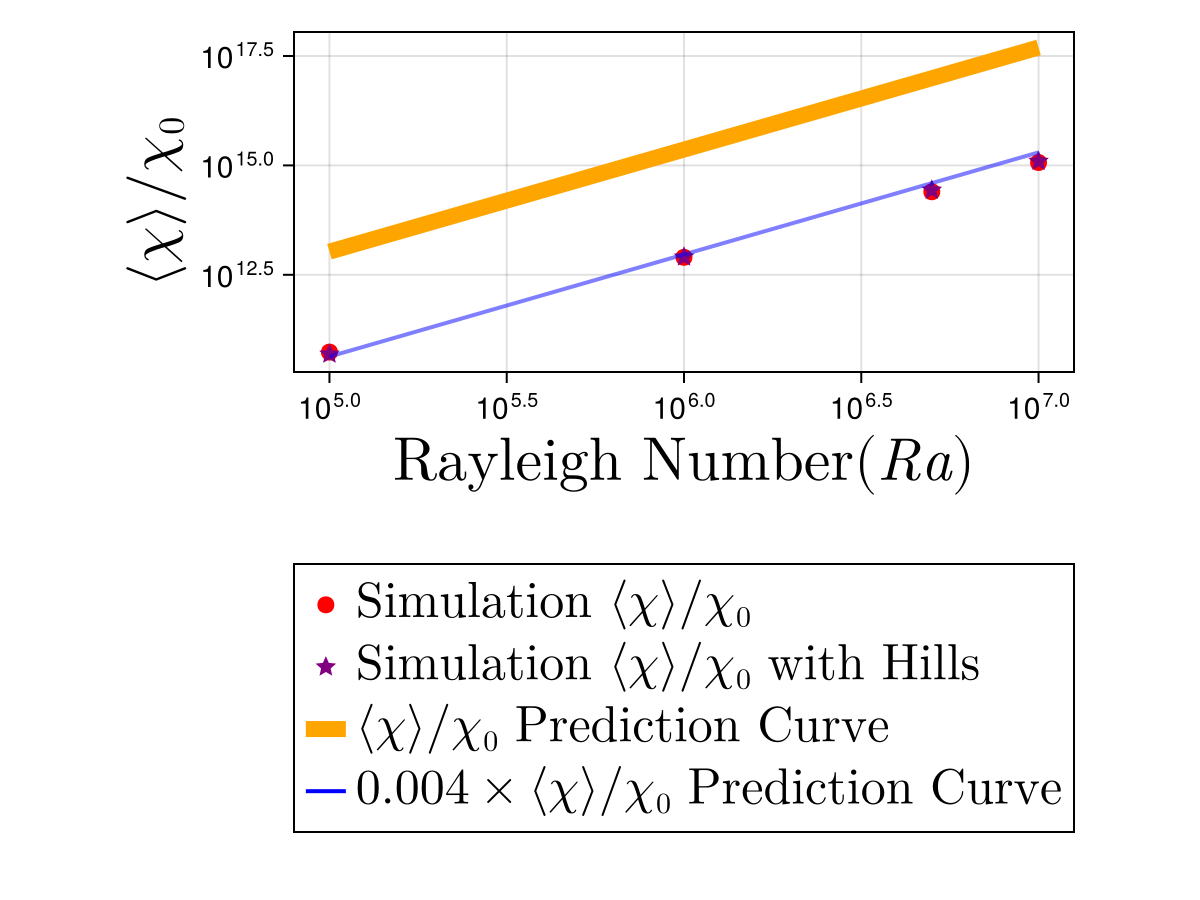

In [13]:
f_χ_scatter = Figure()
ax_χ_scatter = Axis(f_χ_scatter[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\langle{\chi}\rangle / \chi_0")

ax_χ_scatter.xlabelsize = 30
ax_χ_scatter.ylabelsize = 30
ax_χ_scatter.titlesize = 30
ax_χ_scatter.xticklabelsize = 15
ax_χ_scatter.yticklabelsize = 15

Ra_vals = Float64[]
χ_means = Float64[]
#χ_theories_from_sim = Float64[]
χ_theories_from_brain = Float64[]
χ_mean_hills = Float64[]

for ds in list_of_datasets
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    χ_mean = dissipation_analysis(ds, "χ")[3] ./ (κ^5 / H^8) # nondimensionalize χ_mean
    #χ_sim_theory = dissipation_analysis(ds, "χ")[1] ./ (κ^5 / H^8) # nondimensionalize χ_sim_theory

    push!(Ra_vals, Ra)
    push!(χ_means, χ_mean)
    push!(χ_theories_from_brain, 4.57 * 2^(7/3) * Ra^(7/3))
    #push!(ε_theories_from_sim, ε_sim_theory)
end

for ds in list_hill_datasets
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    χ_mean_hill = dissipation_analysis(ds, "χ")[3] ./ (κ^5 / H^8) # nondimensionalize χ_mean

    push!(χ_mean_hills, χ_mean_hill)
end


#plot the scatter points
scatter!(ax_χ_scatter, Ra_vals, χ_means, label=L"\text{Simulation } \langle{\chi}\rangle / \chi_0", markersize=12, color=:red)
scatter!(ax_χ_scatter, Ra_vals, χ_mean_hills, label=L"\text{Simulation } \langle{\chi}\rangle / \chi_0 \text{ with Hills}", marker = :star5, markersize=12, color=:purple)
#theoretical prediction curve
lines!(ax_χ_scatter, Ra_vals, χ_theories_from_brain, label=L"\langle{\chi}\rangle / \chi_0 \text{ Prediction Curve}", linewidth=8, color=:orange)
#lines!(ax_χ_scatter, Ra_vals, χ_theories_from_brain .* 0.1, label=L"0.1 \times \langle{\chi}\rangle / \chi_0 \text{ Prediction Curve}", linewidth=4, color=:green)
lines!(ax_χ_scatter, Ra_vals, χ_theories_from_brain .* 0.004, label=L"0.004 \times \langle{\chi}\rangle / \chi_0 \text{ Prediction Curve}", linewidth=2, color=:blue, alpha=0.5)
#lines!(ax_χ_scatter, Ra_vals, χ_theories_from_sim, label = "Theoretical χ from Simulation Parameters")

Legend(f_χ_scatter[2,1], ax_χ_scatter, labelsize=25)
f_χ_scatter